# FingerPrint-Based Multi-Layer Perceptron

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import pandas as pd
import numpy as np
from pyprojroot import here
import joblib
import yaml
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import torch
from torch.utils.data import DataLoader
from dl_hplc_smrt.utils import  train_with_early_stopping, evaluate_pytorch_regressor, plot_results
from dl_hplc_smrt.data.torch_data_tools import SklearnPipelineDataset
from dl_hplc_smrt.models.mlp_models import ComplexMultilayerPerceptron
from dl_hplc_smrt.data.data_transformers import SmilesToMolTransformer as STM
from dl_hplc_smrt.data.data_transformers import MolToFingerPrintTransformer as MTFP

In [3]:
sns.set_style("whitegrid")

In [4]:
RAW_DATA_PATH = here() / "data" / "raw"
INTERIM_DATA_PATH = here() / "data" / "interim"
PROCESSED_DATA_PATH = here() / "data" / "processed"
SAVED_MODELS_PATH =  here() / "models"
SAVED_MULTILAYER_PERCEPTRON_MODEL_PATH = SAVED_MODELS_PATH / "multilayer_perceptron"
CONFIG_PATH =  here() / "configs"
MULTILAYER_PERCEPTRON_CONFIG_PATH =  CONFIG_PATH / "models" / "multilayer_perceptron"

### Read the SMILES Sets (Train, Validation, Test)

In [5]:
x_train_ret = np.load(PROCESSED_DATA_PATH / "X_train_set_retained.npy", allow_pickle=True).reshape(-1,1)
x_val_ret = np.load(PROCESSED_DATA_PATH / "X_val_set_retained.npy", allow_pickle=True).reshape(-1,1)
x_test_ret = np.load(PROCESSED_DATA_PATH / "X_test_set_retained.npy", allow_pickle=True).reshape(-1,1)
print(x_train_ret.shape, x_val_ret.shape, x_test_ret.shape)
x_train_ret[0:5,:]

(59593, 1) (6623, 1) (10710, 1)


array([['COc1ccc(CC(O)=NC2CCN(c3nnc4ccccn34)CC2)cc1'],
       ['CCc1noc(N=C(C)O)c1-c1ccc(OC)c(S(=O)(=O)N2CC=C(c3ccccc3)CC2)c1'],
       ['CN(C)CCCN=C(O)C1CCN(c2nc3ccc(-c4cccnc4)nc3s2)CC1'],
       ['CCOC(=O)c1c(S(=O)(=O)N2CCc3ccccc3C2)c(C)n(C)c1C'],
       ['Cc1cc(C)c(N=C(O)Cn2cnc3nc(N4CCC(C(O)=NC5CC5)CC4)sc3c2=O)c(C)c1']],
      dtype=object)

In [6]:
y_train_ret = np.load(PROCESSED_DATA_PATH / "y_train_set_retained.npy", allow_pickle=True)
y_val_ret = np.load(PROCESSED_DATA_PATH / "y_val_set_retained.npy", allow_pickle=True)
y_test_ret = np.load(PROCESSED_DATA_PATH / "y_test_set_retained.npy", allow_pickle=True)
print(y_train_ret.shape, y_val_ret.shape, y_test_ret.shape)
y_train_ret[0:5]

(59593,) (6623,) (10710,)


array([626.4, 917.6, 543.4, 989.2, 754.4])

### DataSets and DataLoaders

In [7]:
fps_pipeline = Pipeline([    
    ("mol_converter", STM()),
    ("fp_transformer", MTFP(fp_type="rdkit", radius=3, fp_size=1024, dense=True, counts=True)),
    ("standard_scaler", StandardScaler()),
    ("variance_thres", VarianceThreshold(threshold= 0.0)),# Remove constant all-zero features    
    ])

In [8]:
# create Tensor datasets
train_data = SklearnPipelineDataset(x_train_ret, y_train_ret, sklearn_pipeline=fps_pipeline, fit=True)
valid_data = SklearnPipelineDataset(x_val_ret, y_val_ret, sklearn_pipeline=fps_pipeline, fit=False)

In [9]:
# make sure to SHUFFLE your data
train_loader_50 = DataLoader(train_data, shuffle=True, batch_size=50)
train_loader_100 = DataLoader(train_data, shuffle=True, batch_size=100)
train_loader_150 = DataLoader(train_data, shuffle=True, batch_size=150)
val_loader = DataLoader(valid_data, shuffle=False, batch_size=100) #No need to shuffle

In [10]:
# obtain one batch of training data
dataiter = iter(train_loader_50)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x[0])
print()
print('Sample label size: ', sample_y.size()) # batch_size
print('Sample label: \n', sample_y)

Sample input size:  torch.Size([50, 968])
Sample input: 
 tensor([ 3.9773e-01, -2.6492e-02,  5.3562e-01,  2.0636e-01, -4.0964e-03,
         5.2871e-01, -1.1587e-02, -8.5651e-02, -1.5485e-02, -9.3180e-02,
        -3.2547e-02, -2.2886e-01, -3.4643e-02, -2.4925e-02, -2.0616e-01,
        -3.7364e-01, -7.9712e-01,  6.2296e+00, -2.6345e-02, -1.3807e-01,
        -2.1378e-02, -1.8376e-01, -9.3573e-02, -2.2429e-01, -4.0964e-03,
        -5.6698e-01,  9.4505e-01, -1.5770e-01, -2.7053e-01, -4.0964e-03,
        -1.2764e-02, -1.1841e-01, -4.7493e-01, -2.7693e-01, -2.6239e-02,
         3.3840e-02, -1.1245e-01, -2.3719e-01, -8.7032e-02, -6.4910e-02,
        -9.5587e-03, -1.5720e-01, -5.6887e-01, -1.9713e-02, -2.6870e-01,
        -8.7998e-02, -1.2290e-02, -9.5587e-03, -8.6920e-01, -1.1411e-01,
        -6.1572e-02, -4.6757e-02, -1.1965e-01, -2.3787e-01,  1.0038e+00,
        -5.1358e-01, -3.2633e-01, -5.5980e-01, -8.8006e-02, -1.1164e-01,
        -1.0226e-02, -5.2403e-01, -5.5380e-02,  1.2837e+00, -2.308

## Let's Instanciate a Small MLP

In [11]:
train_data.X.shape[1]

968

In [12]:
my_first_mlp = ComplexMultilayerPerceptron(
    num_features=train_data.X.shape[1],
    encoder_hidden_layers_dim=[32,32],
    processer_hidden_layers_dim= [16], 
    output_dim=1,
    dropout_prob=0.25,
    activation="relu",
)

In [13]:
my_first_mlp

ComplexMultilayerPerceptron(
  (activation_layer): ReLU()
  (encoder): MultiLayerPerceptron(
    (activation_layer): ReLU()
    (linear_layers): ModuleList(
      (0): LinearLayerPerceptron(
        (fc): Linear(in_features=968, out_features=32, bias=True)
        (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (dropout): Dropout(p=0.25, inplace=False)
      )
      (1): LinearLayerPerceptron(
        (fc): Linear(in_features=32, out_features=32, bias=True)
        (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (dropout): Dropout(p=0.25, inplace=False)
      )
    )
  )
  (processer): MultiLayerPerceptron(
    (activation_layer): ReLU()
    (linear_layers): ModuleList(
      (0): LinearLayerPerceptron(
        (fc): Linear(in_features=32, out_features=16, bias=True)
        (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
   

In [14]:
history = train_with_early_stopping(
    model=my_first_mlp,
    train_loader=train_loader_100,
    val_loader=val_loader,
    criterion=torch.nn.MSELoss(),
    eval_criterion=torch.nn.L1Loss(),
    optimizer=torch.optim.Adam(my_first_mlp.parameters()),
    checkpoint_path=INTERIM_DATA_PATH / "best_first_mlp.pt",
    delta=0.5,
    epochs=150,
    patience=15,
    evals_per_epoch=10,
    )


Epoch 0/150 - Train Loss: 687417.3019 - Val Loss: 683223.4896 - Val Eval Loss: 807.9124
	Validation evaluation loss improved from inf to 807.9124. Saving model checkpoint.
Epoch 0/150 - Train Loss: 687378.5368 - Val Loss: 682185.0145 - Val Eval Loss: 807.3523
	Validation evaluation loss improved from 807.9124 to 807.3523. Saving model checkpoint.
Epoch 0/150 - Train Loss: 683577.1868 - Val Loss: 680665.8575 - Val Eval Loss: 806.5291
	Validation evaluation loss improved from 807.3523 to 806.5291. Saving model checkpoint.
Epoch 0/150 - Train Loss: 684647.0888 - Val Loss: 678431.1709 - Val Eval Loss: 805.2774
	Validation evaluation loss improved from 806.5291 to 805.2774. Saving model checkpoint.
Epoch 0/150 - Train Loss: 683632.6911 - Val Loss: 676190.6811 - Val Eval Loss: 804.0185
	Validation evaluation loss improved from 805.2774 to 804.0185. Saving model checkpoint.
Epoch 0/150 - Train Loss: 682796.4863 - Val Loss: 673152.7941 - Val Eval Loss: 802.2982
	Validation evaluation loss impr

<Axes: >

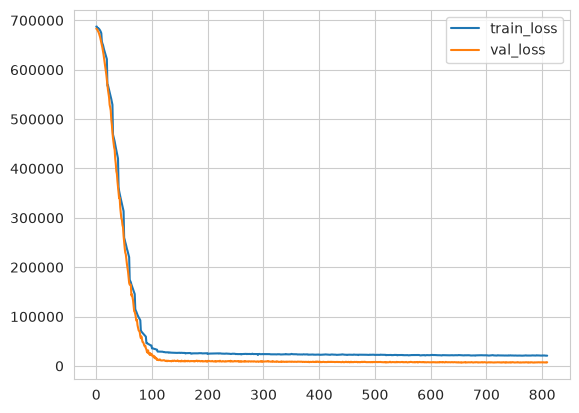

In [15]:
history.loc[:,['train_loss','val_loss']].plot()

<Axes: >

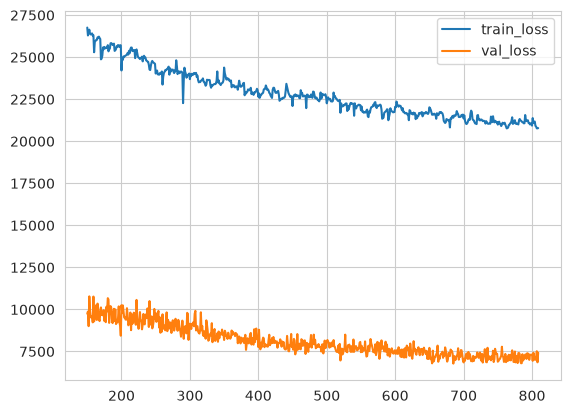

In [16]:
history.loc[150:,['train_loss','val_loss']].plot()

<Axes: >

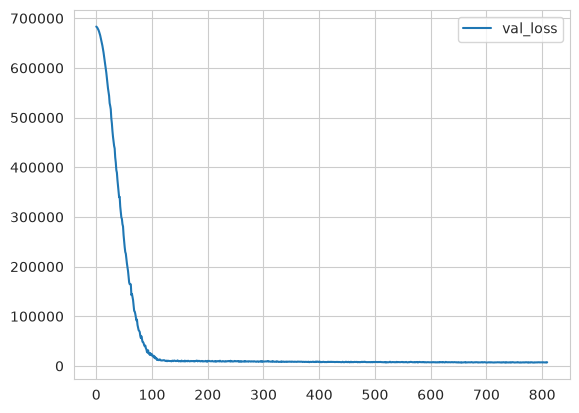

In [17]:
history.loc[:,['val_loss']].plot()

#### Load Best Model

In [18]:
checkpoint = torch.load(INTERIM_DATA_PATH / "best_first_mlp.pt")

In [19]:
my_first_mlp.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [20]:
evaluate_pytorch_regressor(
    model=my_first_mlp,dataloaders={'train': train_loader_100, 'Validation': val_loader}, scores={
        "r**2": r2_score,
        "mae": mean_absolute_error,
        "mse": mean_squared_error,
        "rmse": root_mean_squared_error
})

,dataset,r**2,mae,mse,rmse
0,train,0.803849,53.834183,6002.264648,77.474281
1,Validation,0.775074,56.450211,6879.311035,82.941612


So far we cannot improve over the best validation baseline model mae (52.9) but we improved the rmse of our best baseline models (random forest/extra-trees) (81.5). But it also looks like it performs very similar for train and validation, so it can be optimized

## First Optimization

Let's assume that what we learn while building baseline models about generating fingerpirnts stands for the MLP and focus on trying a few hyperparameters of the MLP

In [21]:
datasets = {'train': train_loader_100, 'Validation': val_loader}
scores = {
    "r**2": r2_score,
    "mae": mean_absolute_error,
    "mse": mean_squared_error,
    "rmse": root_mean_squared_error
    }

In [22]:
model_counter = 0
model_evaluations={}
model_descriptions={}
model_val_sumary = pd.DataFrame(columns=['model_counter','encoder_layers','processer_layers','dropout_probs','r2','mae','mse','rmse'])
for encoder_layers, processer_layers, dropout_probs in itertools.product(
    [[32,32],[64,64], [32,32,32]],
    [[8], [16], [8,8]],
    [0.0, 0.25, 0.5]
):
    print(f"Encoder layers: {encoder_layers}, Processer layers: {processer_layers}, Dropout probs: {dropout_probs}")
    mlp_model = ComplexMultilayerPerceptron(
        num_features=train_data.X.shape[1],
        encoder_hidden_layers_dim=encoder_layers,
        processer_hidden_layers_dim=processer_layers,
        output_dim=1,
        dropout_prob=dropout_probs,
        activation="relu",
    )
    history = train_with_early_stopping(
        model=mlp_model,
        train_loader=train_loader_100,
        val_loader=val_loader,
        criterion=torch.nn.MSELoss(),
        eval_criterion=torch.nn.L1Loss(),
        optimizer=torch.optim.Adam(mlp_model.parameters()),
        checkpoint_path=INTERIM_DATA_PATH / "temp_mlp_model.pt",
        delta=0.5,
        epochs=150,
        patience=5,
        evals_per_epoch=10,
    )
    checkpoint = torch.load(INTERIM_DATA_PATH / "temp_mlp_model.pt")
    mlp_model.load_state_dict(checkpoint["model_state_dict"])
    model_evaluations[model_counter] = evaluate_pytorch_regressor(
        model=mlp_model,dataloaders=datasets, scores=scores
    )
    model_descriptions[model_counter] = {
        "encoder_layers": encoder_layers,
        "processer_layers": processer_layers,
        "dropout_probs": dropout_probs
    }
    model_val_sumary.loc[model_counter] = [model_counter, encoder_layers, processer_layers, dropout_probs] + [model_evaluations[model_counter][score][1] for score in scores]
    model_counter += 1
    


Encoder layers: [32, 32], Processer layers: [8], Dropout probs: 0.0
Epoch 0/150 - Train Loss: 683104.8655 - Val Loss: 682467.3903 - Val Eval Loss: 807.4596
	Validation evaluation loss improved from inf to 807.4596. Saving model checkpoint.
Epoch 0/150 - Train Loss: 682192.4107 - Val Loss: 681770.9832 - Val Eval Loss: 807.0594
	Validation evaluation loss improved from 807.4596 to 807.0594. Saving model checkpoint.
Epoch 0/150 - Train Loss: 681953.7626 - Val Loss: 680865.7793 - Val Eval Loss: 806.5361
	Validation evaluation loss improved from 807.0594 to 806.5361. Saving model checkpoint.
Epoch 0/150 - Train Loss: 680348.5481 - Val Loss: 679655.1811 - Val Eval Loss: 805.8497
	Validation evaluation loss improved from 806.5361 to 805.8497. Saving model checkpoint.
Epoch 0/150 - Train Loss: 681496.7771 - Val Loss: 678308.9746 - Val Eval Loss: 805.0782
	Validation evaluation loss improved from 805.8497 to 805.0782. Saving model checkpoint.
Epoch 0/150 - Train Loss: 680307.8531 - Val Loss: 67

In [23]:

model_val_sumary.sort_values('mae', ascending=True).head(30)

,model_counter,encoder_layers,processer_layers,dropout_probs,r2,mae,mse,rmse
15,15,"[64, 64]","[8, 8]",0.00,0.827928,46.643787,5262.783691,72.545044
9,9,"[64, 64]",[8],0.00,0.820109,47.449276,5501.932617,74.175011
24,24,"[32, 32, 32]","[8, 8]",0.00,0.822409,47.654697,5431.595215,73.699356
12,12,"[64, 64]",[16],0.00,0.815560,48.358036,5641.070312,75.107056
18,18,"[32, 32, 32]",[8],0.00,0.817583,48.431602,5579.198730,74.694031
3,3,"[32, 32]",[16],0.00,0.817138,48.676926,5592.795898,74.784996
21,21,"[32, 32, 32]",[16],0.00,0.809633,48.889931,5822.335938,76.304230
0,0,"[32, 32]",[8],0.00,0.813710,49.036270,5697.640137,75.482712
6,6,"[32, 32]","[8, 8]",0.00,0.781162,55.577152,6693.135254,81.811584
13,13,"[64, 64]",[16],0.25,0.751658,61.451569,7595.504395,87.152191


It appears that models without regularization and 4-layers are the more succesful. We will carry out extra optimization loop 

## Second Optimization

Let's test a smaler amount of dropout regularization and let's use more pacience

In [24]:
datasets = {'train': train_loader_100, 'Validation': val_loader}
scores = {
    "r**2": r2_score,
    "mae": mean_absolute_error,
    "mse": mean_squared_error,
    "rmse": root_mean_squared_error
    }

In [25]:
model_counter = 0
model_evaluations={}
model_descriptions={}
model_val_sumary_2 = pd.DataFrame(columns=['model_counter','encoder_layers','processer_layers','dropout_probs','r2','mae','mse','rmse'])
for encoder_layers, processer_layers, dropout_probs in zip(
    [[32,32,32],[32,32,32],[32,32,32],
      [64,64],[64,64],[64,64],[64,64],
      [64,32,32],[64,32,32],[64,32,32],[64,32,32],
      [64,32],[64,32],[64,32],[64,32],],
    [[8], [16], [8,8], [16,8],
     [8], [16], [8,8], [16,8],
     [8], [16], [8,8], [16,8],
     [8], [16], [8,8], [16,8],],
    [0.0, 0.0, 0.0, 0.0, 
     0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 
     0.0, 0.0, 0.0, 0.0,]
):
    print(f"Encoder layers: {encoder_layers}, Processer layers: {processer_layers}, Dropout probs: {dropout_probs}")
    mlp_model = ComplexMultilayerPerceptron(
        num_features=train_data.X.shape[1],
        encoder_hidden_layers_dim=encoder_layers,
        processer_hidden_layers_dim=processer_layers,
        output_dim=1,
        dropout_prob=dropout_probs,
        activation="relu",
    )
    history = train_with_early_stopping(
        model=mlp_model,
        train_loader=train_loader_100,
        val_loader=val_loader,
        criterion=torch.nn.MSELoss(),
        eval_criterion=torch.nn.L1Loss(),
        optimizer=torch.optim.Adam(mlp_model.parameters()),
        checkpoint_path=INTERIM_DATA_PATH / "temp_mlp_model.pt",
        delta=0.5,
        epochs=150,
        patience=10,
        evals_per_epoch=10,
    )
    checkpoint = torch.load(INTERIM_DATA_PATH / "temp_mlp_model.pt")
    mlp_model.load_state_dict(checkpoint["model_state_dict"])
    model_evaluations[model_counter] = evaluate_pytorch_regressor(
        model=mlp_model,dataloaders=datasets, scores=scores
    )
    model_descriptions[model_counter] = {
        "encoder_layers": encoder_layers,
        "processer_layers": processer_layers,
        "dropout_probs": dropout_probs
    }
    model_val_sumary_2.loc[model_counter] = [model_counter, encoder_layers, processer_layers, dropout_probs] + [model_evaluations[model_counter][score][1] for score in scores]
    model_counter += 1
    


Encoder layers: [32, 32, 32], Processer layers: [8], Dropout probs: 0.0
Epoch 0/150 - Train Loss: 677933.1229 - Val Loss: 682035.4082 - Val Eval Loss: 807.2464
	Validation evaluation loss improved from inf to 807.2464. Saving model checkpoint.
Epoch 0/150 - Train Loss: 679730.5299 - Val Loss: 681359.1386 - Val Eval Loss: 806.8702
	Validation evaluation loss improved from 807.2464 to 806.8702. Saving model checkpoint.
Epoch 0/150 - Train Loss: 681707.6689 - Val Loss: 680454.0325 - Val Eval Loss: 806.3581
	Validation evaluation loss improved from 806.8702 to 806.3581. Saving model checkpoint.
Epoch 0/150 - Train Loss: 683051.7153 - Val Loss: 679190.2469 - Val Eval Loss: 805.6241
	Validation evaluation loss improved from 806.3581 to 805.6241. Saving model checkpoint.
Epoch 0/150 - Train Loss: 680947.4151 - Val Loss: 677383.1539 - Val Eval Loss: 804.5712
	Validation evaluation loss improved from 805.6241 to 804.5712. Saving model checkpoint.
Epoch 0/150 - Train Loss: 680741.8533 - Val Loss

In [26]:

model_val_sumary_2.sort_values('mae', ascending=True).head(20)

,model_counter,encoder_layers,processer_layers,dropout_probs,r2,mae,mse,rmse
7,7,"[64, 32, 32]","[16, 8]",0.0,0.836986,44.598530,4985.751953,70.609856
4,4,"[64, 64]",[8],0.0,0.831131,45.380074,5164.820801,71.866684
11,11,"[64, 32]","[16, 8]",0.0,0.829187,45.549374,5224.273438,72.279137
13,13,"[64, 32]",[16],0.0,0.825080,45.563622,5349.905273,73.143044
8,8,"[64, 32, 32]",[8],0.0,0.832153,45.578636,5133.578125,71.648994
10,10,"[64, 32, 32]","[8, 8]",0.0,0.830082,45.735382,5196.901855,72.089539
5,5,"[64, 64]",[16],0.0,0.831172,45.754585,5163.588867,71.858116
14,14,"[64, 32]","[8, 8]",0.0,0.829100,45.894913,5226.953125,72.297668
3,3,"[64, 64]","[16, 8]",0.0,0.824683,46.233231,5362.029297,73.225876
0,0,"[32, 32, 32]",[8],0.0,0.824259,46.427219,5374.995117,73.314362


## Reoptimizing and Saving the Best Model

In [27]:
final_mlp_model = ComplexMultilayerPerceptron(
        num_features=train_data.X.shape[1],
        encoder_hidden_layers_dim=[64, 32, 32],
        processer_hidden_layers_dim=[16,8],
        output_dim=1,
        dropout_prob=0.0,
        activation="relu",
    )

In [28]:
history = train_with_early_stopping(
        model=final_mlp_model,
        train_loader=train_loader_100,
        val_loader=val_loader,
        criterion=torch.nn.MSELoss(),
        eval_criterion=torch.nn.L1Loss(),
        optimizer=torch.optim.Adam(final_mlp_model.parameters()),
        checkpoint_path=SAVED_MULTILAYER_PERCEPTRON_MODEL_PATH / "multilayer_perceptron_rdkit_pipeline_2026_07_03_v0.pt",
        delta=0.1,
        epochs=250,
        patience=25,
        evals_per_epoch=15,
    )

Epoch 0/250 - Train Loss: 676123.7051 - Val Loss: 683556.2851 - Val Eval Loss: 808.1067
	Validation evaluation loss improved from inf to 808.1067. Saving model checkpoint.
Epoch 0/250 - Train Loss: 677790.1013 - Val Loss: 682842.1737 - Val Eval Loss: 807.6726
	Validation evaluation loss improved from 808.1067 to 807.6726. Saving model checkpoint.
Epoch 0/250 - Train Loss: 680332.0993 - Val Loss: 682480.9491 - Val Eval Loss: 807.4571
	Validation evaluation loss improved from 807.6726 to 807.4571. Saving model checkpoint.
Epoch 0/250 - Train Loss: 682519.6262 - Val Loss: 681930.6425 - Val Eval Loss: 807.1367
	Validation evaluation loss improved from 807.4571 to 807.1367. Saving model checkpoint.
Epoch 0/250 - Train Loss: 682655.0720 - Val Loss: 681321.4106 - Val Eval Loss: 806.7913
	Validation evaluation loss improved from 807.1367 to 806.7913. Saving model checkpoint.
Epoch 0/250 - Train Loss: 681177.5559 - Val Loss: 680441.9316 - Val Eval Loss: 806.3076
	Validation evaluation loss impr

In [29]:
checkpoint = torch.load(SAVED_MULTILAYER_PERCEPTRON_MODEL_PATH / "multilayer_perceptron_rdkit_pipeline_2026_07_03_v0.pt")
final_mlp_model.load_state_dict(checkpoint["model_state_dict"])
final_mlp_model_evaluations = evaluate_pytorch_regressor(
        model=final_mlp_model,dataloaders=datasets, scores=scores
    )
final_mlp_model_evaluations

,dataset,r**2,mae,mse,rmse
0,train,0.918150,32.050369,2504.612305,50.046101
1,Validation,0.830461,44.737892,5185.335449,72.009270


In [30]:
device = 'cpu'
final_mlp_model.eval()
with torch.no_grad():
    y_val_pred = []
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = final_mlp_model(inputs)
        y_val_pred.extend(outputs.cpu().numpy())
y_val_pred = np.array(y_val_pred).reshape(-1)

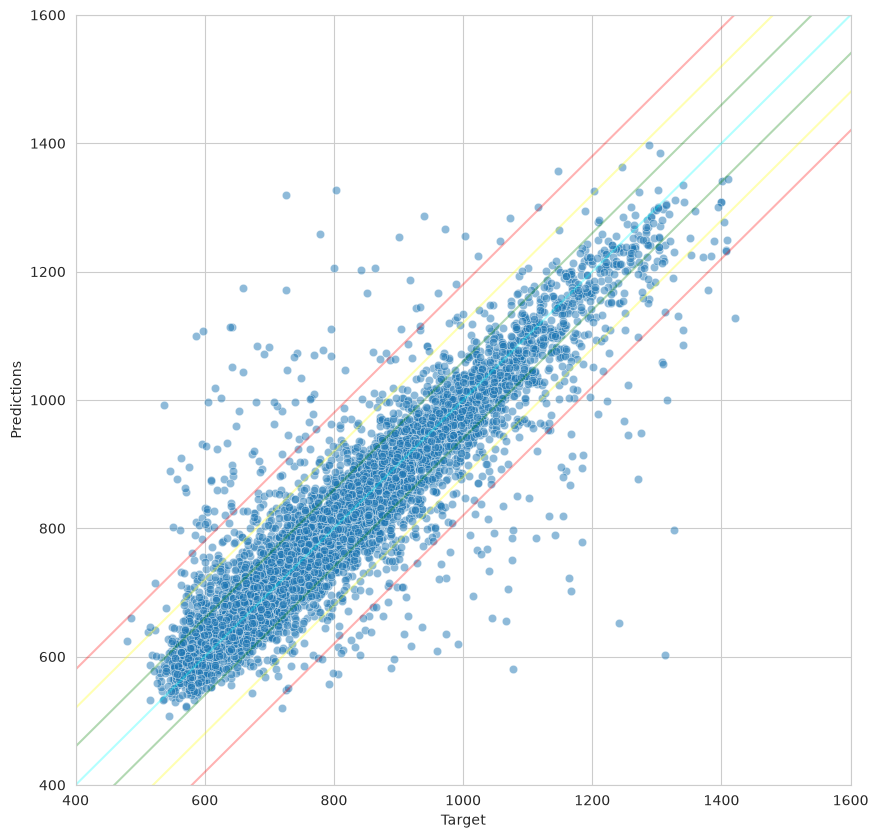

In [31]:
my_fig = plot_results(y_val_ret, y_val_pred)

<Axes: >

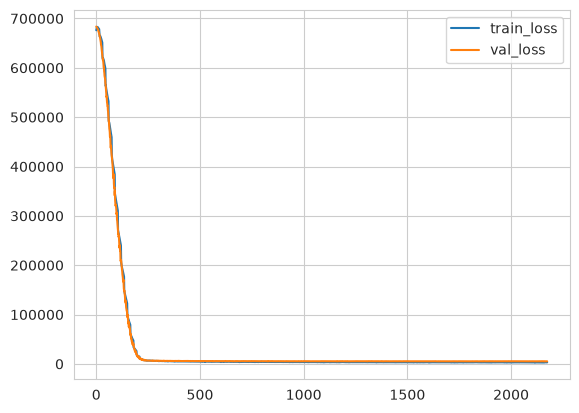

In [32]:
history.loc[:,['train_loss','val_loss']].plot()

<Axes: >

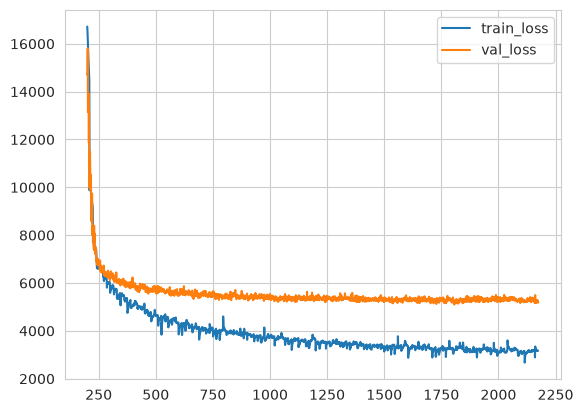

In [35]:
history.loc[200:,['train_loss','val_loss']].plot()